## **Build an Auto encoder, train it with MNIST and analyse the extracted features.**


#### 🔹**Reason behind choosing this project along with the MNIST dataset instead of CIFAR-10 data set**.
  * MNIST dataset in autoencoder projects, as opposed to CIFAR-10, provides several advantages: simpler structure, easier experimentation, and a widely used benchmark. MNIST's simplicity makes it ideal for understanding the fundamentals of autoencoders, while CIFAR-10's complexity can be better suited for more advanced projects(convolutional autoencoders and require handling complex image data).

       * MNIST consists of 28x28 grayscale images of handwritten digits, while CIFAR-10 contains 32x32 color images of various objects. This makes MNIST easier to work with, especially for beginners or those new to autoencoders.
       * Due to the smaller size and simpler structure of the data, MNIST generally allows for faster training of autoencoders, which can be beneficial for experimenting with different architectures and parameters.
       * CIFAR-10, with its color images and diverse object categories, is a good choice for exploring more advanced autoencoder architectures and applications.



🔹 **Short Discussion about the project requirement, MNIST dataset, importance of feature extraction, how the autoencoder analyse the only important feature anf finally recreate the lossy input as output in short.**

  * This project aimed to build and analyze an autoencoder for feature extraction using the MNIST dataset. We explored the importance of feature extraction for representing data efficiently. The autoencoder achieved this by learning to compress the MNIST images into a lower-dimensional latent space, analyzing and retaining only the most crucial features needed. Subsequently, it used these features to reconstruct a lossy, but visually similar, version of the original input image, demonstrating its ability to capture essential data characteristics.

#### 🔹 **Hyperparameter Selection Rationale:**

In determining the architecture of our autoencoder, we considered established heuristics and conducted empirical testing. For instance, the selection of 128 neurons in the hidden layer aligns with the guideline suggesting a size between the input and output layers. We experimented with various configurations, including 64, 128, and 256 neurons, and observed that 128 provided a balance between performance and computational efficiency. Similarly, for the bottleneck layer, we tested sizes of 16, 20, and 32 neurons, ultimately selecting 20 based on reconstruction accuracy and latent space interpretability.

several approaches are commonly considered here ( from research paper Heaton, Research Gate,) :

* Rule of Thumb Methods (Between Input and Output Sizes,Two-Thirds Rule, Less Than Twice the Input Size)
* Empirical Testing
* Cross-Validation
* Regularization Considerations




### **Steps**:

      > PHASE 1: IMPLEMENTATION
      > PHASE 2: ANALYSIS OF EXTRACTED FEATURES

> * Data loading and preprocessing
> * Building the Autoencoder (Encoder + Decoder)
> * Training the Autoencoder
> * Visualizing the reconstruction vs original
> * Plotting the training/validation loss
> * Analyzing the extracted features (latent space, neuron activation, etc.)

### 🔹 Step 1: Load and Preprocess MNIST Data
I have used TensorFlow/Keras to get the MNIST dataset.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras import regularizers
from tensorflow.keras.optimizers import Adam

# Loading the MNIST data
(x_train, _), (x_test, y_test) = mnist.load_data()

# Normalize the data to [0, 1]
x_train = x_train.astype('float32') / 255.
x_test = x_test.astype('float32') / 255.

# Flatten the images
x_train = x_train.reshape((len(x_train), 28 * 28))
x_test = x_test.reshape((len(x_test), 28 * 28))

print("Training data shape:", x_train.shape)
print("Test data shape:", x_test.shape)


11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Training data shape: (60000, 784)
Test data shape: (10000, 784)


### key Points:

> * MNIST Dataset: A collection of 70,000 handwritten digits (0 - 9), commonly used in machine learning. Each image is 28x28 pixels.
> * Importing Libraries:
tensorflow.keras: Helps build and train neural networks.
> * numpy and matplotlib: For numerical operations and visualizations.
> * Data Loading: mnist.load_data() automatically fetches and splits the dataset into training and test sets.
> * Normalization:Image pixel values range from 0 to 255.We scale them down to between 0 and 1 by dividing by 255.This helps the neural network train faster and more effectively.
> * Flattening:Neural networks (like fully connected layers) expect 1D vectors as input.
Each 28×28 image is reshaped to a 784-dimensional vector.


### 🔹Step 2: Displays 10 sample images from both x_train and x_test

* Visualize a few examples from the training and test sets right after loading and preprocessing the MNIST data. This confirms that our data is correctly loaded and normalized.

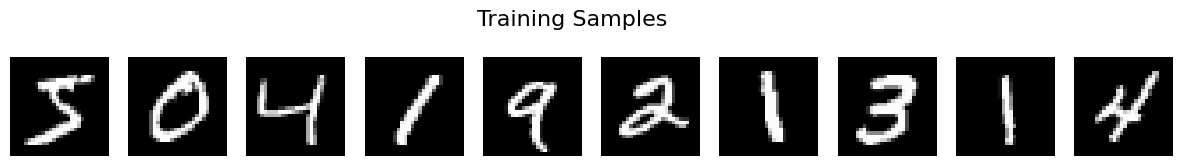

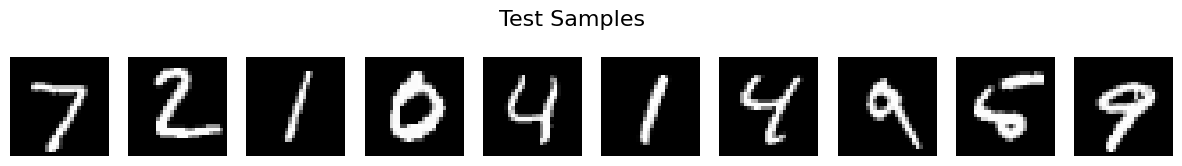

In [ ]:
# Visualize some samples from the training and test datasets
def plot_sample_images(data, labels=None, title='Sample Images', num_samples=10):
    plt.figure(figsize=(15, 2))
    for i in range(num_samples):
        ax = plt.subplot(1, num_samples, i + 1)
        plt.imshow(data[i].reshape(28, 28), cmap='gray')
        if labels is not None:
            plt.title(str(labels[i]))
        plt.axis('off')
    plt.suptitle(title, fontsize=16)
    plt.show()

# Show training samples
plot_sample_images(x_train, title='Training Samples')

# Show test samples
plot_sample_images(x_test, title='Test Samples')


### Auto Encoder
* The Encoder: Compresses the input image to a lower-dimensional representation (latent space).
* The Decoder: Reconstructs the original image from that compressed form.
* The Autoencoder Model: Combines both encoder and decoder.

### 🔷 Step 2: Build the Encoder, Decoder, and Autoencoder

In [ ]:
# Input placeholder
input_img = Input(shape=(784,))

# Encoder part
encoded = Dense(128, activation='relu')(input_img)
encoded = Dense(64, activation='relu')(encoded)
encoded = Dense(32, activation='relu')(encoded)  # Latent space

# Decoder part
decoded = Dense(64, activation='relu')(encoded)
decoded = Dense(128, activation='relu')(decoded)
decoded = Dense(784, activation='sigmoid')(decoded)  # Output: same shape as input

# Full autoencoder model
autoencoder = Model(input_img, decoded)

# Encoder model (for extracting features later)
encoder = Model(input_img, encoded)

# Compile the model
autoencoder.compile(optimizer=Adam(), loss='binary_crossentropy')


### Key Points:

> * Input Layer: Takes a 784-dimensional vector (flattened 28x28 image).
> * Encoder Layers: Gradually reduce the dimensionality:
784 → 128 → 64 → 32 (this 32-dimensional vector is the latent feature representation).
> * Latent Space: This is where the autoencoder “compresses” the essence of the digit. **We'll analyze this layer later to understand what features the network learns.**
> * Decoder Layers: Gradually expand back:
32 → 64 → 128 → 784, trying to reconstruct the original input.
> * Activation Functions: ReLU is used in hidden layers for non-linear transformations. Sigmoid is used in the final layer because pixel values are in the range [0, 1].
> * Model Compilation:Adam optimizer is used for efficient training. Binary Crossentropy loss measures the difference between input and output pixels.


### 🔷 Step 3: Train the Autoencoder & Visualize the Training Process

In [ ]:
# Train the autoencoder
history = autoencoder.fit(
    x_train, x_train,         # Input and target are the same (unsupervised)
    epochs=20,
    batch_size=256,
    shuffle=True,
    validation_data=(x_test, x_test)
)


Epoch 1/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - loss: 0.3324 - val_loss: 0.1596
Epoch 2/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - loss: 0.1526 - val_loss: 0.1325
Epoch 3/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - loss: 0.1298 - val_loss: 0.1207
Epoch 4/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 0.1207 - val_loss: 0.1143
Epoch 5/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 6s 19ms/step - loss: 0.1144 - val_loss: 0.1100
Epoch 6/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 0.1106 - val_loss: 0.1071
Epoch 7/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 0.1077 - val_loss: 0.1051
Epoch 8/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - loss: 0.1051 - val_loss: 0.1022
Epoch 9/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - loss: 0.1030 - val_loss: 0.1003
Epoch 10/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 0.1008 - val_loss: 0.0988
Epoch 11/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 6s 17ms/step - loss: 0.0993 - val_loss: 0.0967
Epoch 12/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 

Now let’s plot the training and validation loss to observe how the model is learning over time.

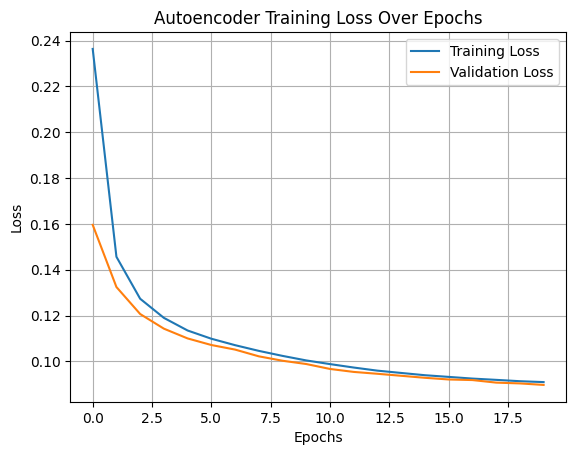

In [ ]:
# Plotting training and validation loss
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Autoencoder Training Loss Over Epochs')
plt.legend()
plt.grid(True)
plt.show()


### Key Points:

> * Training:
    * The model is trained to reconstruct its own input (unsupervised learning). We have used 20 epochs and a batch size of 256 for balanced speed and performance.    **shuffle=True** ensures that each epoch sees the data in a different order.
> * Loss Curve:
    * Helps us visualize how well the model is learning.Ideally, both training and validation loss should decrease smoothly. **If validation loss increases while training loss decreases, it could indicate overfitting.**
> * Why Reconstruct Input?
    * By trying to recreate the input, the model must learn meaningful representations of the data, which is exactly what we want for feature extraction.

### Insight 1 :
The plot 'Autoencoder Training Loss Over Epochs' shows that both the training loss and validation loss decreased consistently over the 20 epochs. This indicates that the autoencoder model is effectively learning to reconstruct the MNIST images. The validation loss tracked closely with the training loss, suggesting that the model is generalizing well and not overfitting to the training data within this number of epochs. The loss appears to be stabilizing towards the end of training, indicating good convergence.

### 🔹 Step 4: Visual Comparison : **Reconstructed vs Original Images**

This step is essential for :

* Visually validating how well our autoencoder is performing.
* Demonstrating the *lossy reconstruction* nature of autoencoders.

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


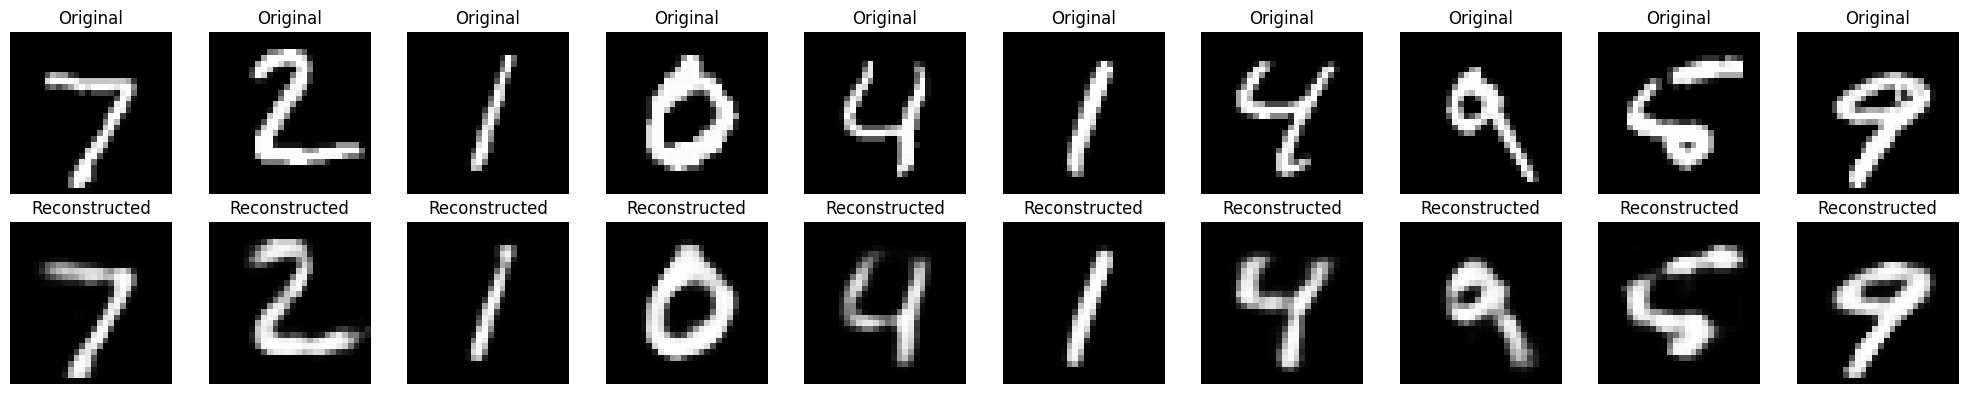

In [ ]:
# Predict the reconstructed images
decoded_imgs = autoencoder.predict(x_test)

# Number of digits to display
n = 10

plt.figure(figsize=(20, 4))
for i in range(n):
    # Display original image
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(x_test[i].reshape(28, 28), cmap='gray')
    plt.title("Original")
    plt.axis('off')

    # Display reconstructed image
    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(decoded_imgs[i].reshape(28, 28), cmap='gray')
    plt.title("Reconstructed")
    plt.axis('off')
plt.tight_layout()
plt.show()


### Key Points:

> * Prediction: We pass the test data through the trained autoencoder to get reconstructed images.
> * Side-by-Side Display:
    * First row: Original test images.
    * Second row: Reconstructed versions produced by the autoencoder.
> * What to Look For: If the model has learned good representations, the reconstructed digits should be clear and similar to the originals. Some fine details may be lost, which is expected in lossy compression.
> * Why This Matters: This visual proof complements the loss graph. It shows the quality of features learned by the encoder for reconstructing digits.

### Insight 2:

The visual comparison reveals that while the autoencoder generally reconstructs digits well, some, like 9 and 5, appear blurrier. This suggests that the model's ability to compress and reconstruct finer details is influenced by the inherent variability and complexity of certain digit forms in the training data, or that the chosen latent space size might not fully capture the necessary information for perfect reconstruction of all digit types. The autoencoder learns features based on the overall data distribution, and differences in quality highlight where the learned compressed representation might be less effective for specific cases.

### 🔷 Step 5: Explore and Visualize Latent Features

We'll now:
* Extract latent features using the encoder
* Visualize them using t-SNE (for **non-linear 2D visualization**)
* Color the features by digit label to see how well the model separated different digits in the compressed space
       Step 5.1 : Extract Features from the Bottleneck Layer

       Step 5.2 : Visualize the Latent Space using t-SNE

In [ ]:

# 5.1 : Extract the latent space representations from the encoder
encoded_imgs = encoder.predict(x_test)


313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


/usr/local/lib/python3.11/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


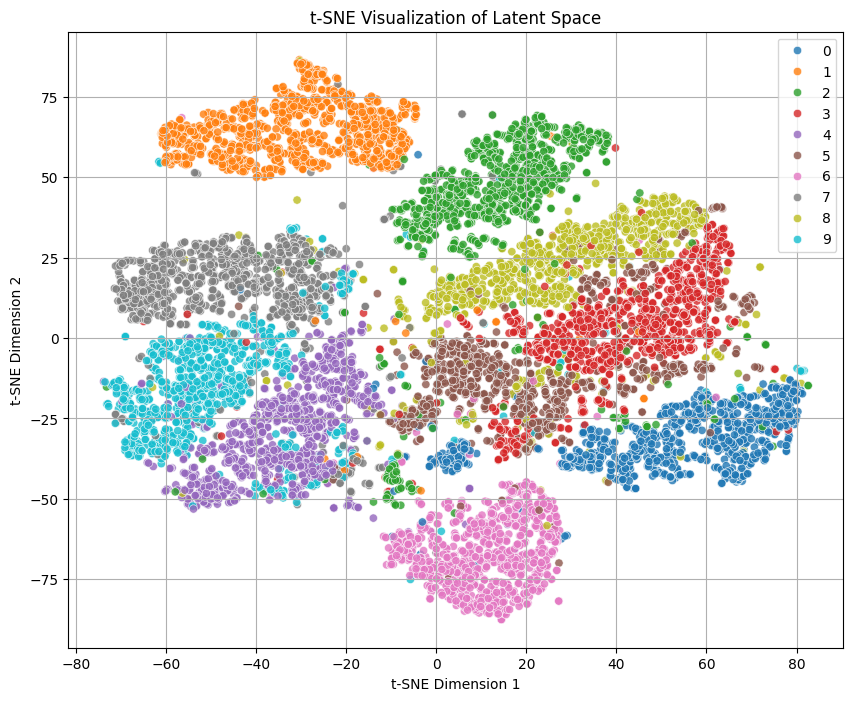

In [ ]:
#5.2 : Visualize the Latent Space using t-SNE

from sklearn.manifold import TSNE
import seaborn as sns

# Reduce to 2D using t-SNE
tsne = TSNE(n_components=2, random_state=42, perplexity=30, n_iter=1000)
tsne_result = tsne.fit_transform(encoded_imgs)

# Plotting
plt.figure(figsize=(10, 8))
sns.scatterplot(
    x=tsne_result[:, 0],
    y=tsne_result[:, 1],
    hue=y_test,
    palette='tab10',
    legend='full',
    alpha=0.8
)
plt.title("t-SNE Visualization of Latent Space")
plt.xlabel("t-SNE Dimension 1")
plt.ylabel("t-SNE Dimension 2")
plt.grid(True)
plt.show()


### Key Points:

> * Encoded Representations:
    * The encoder compresses each 784-pixel image into a 32-dimensional feature vector.
> * Why t-SNE?
    * t-SNE is a technique to reduce high-dimensional data to 2D while preserving local structure (i.e., similar digits stay close).
> * Color by True Label:
    * This shows how well the autoencoder separated digit types, even without using labels during training. **Clear clustering implies the autoencoder has learned distinct, meaningful features**.

{**N.B: Before writing down the insights here I noticed one things, after rerunning the same code, even though the whole nature of clustering is intact,we can see the position change w.r.t clusters**}

### Insights 3:
* The t-SNE visualization of the latent space provides **valuable insight into the features learned by the autoencoder**. As observed, digits like 0, 1, and 6 form distinct and well separated clusters, suggesting that the encoder has learned highly discriminative features for these relatively less variable digit forms.

* However, the clusters for other digits show varying degrees of overlap and sparsity. Notably, the clusters for 3, 5, and 8 are intermingled, indicating that the learned latent features for these digits share significant similarities. This overlap is likely due to the visual resemblance and higher variability in the handwritten forms of these digits, making it more challenging for the autoencoder to learn completely distinct representations in the compressed space.

* Similarly, while the cluster for 2 is somewhat separated, its sparse nature suggests a wider distribution of learned features for this digit. This mixed clustering performance highlights that while the unsupervised training of the autoencoder effectively captures general digit characteristics for reconstruction, the level of feature distinctiveness for downstream tasks like classification varies depending on the inherent visual complexity and variability of the individual digit classes in the training data. The chosen latent space dimension may also limit the model's ability to perfectly disentangle features for visually similar digits.

### 🔷 Step 6: Deep Dive into Latent Features — Neuron Activation Analysis

 Now let's dive into the most analytical and unique part of our project:

Our Aim here is:
 * Which neurons in the bottleneck layer are most active for certain digits ?
 * How specific neurons contribute to representing features of the images ?
 * Get intuition: **"Is there a neuron for loops, curves, or vertical lines"?**

#### 🔸 6.1: Visualize Bottleneck Activations per Image

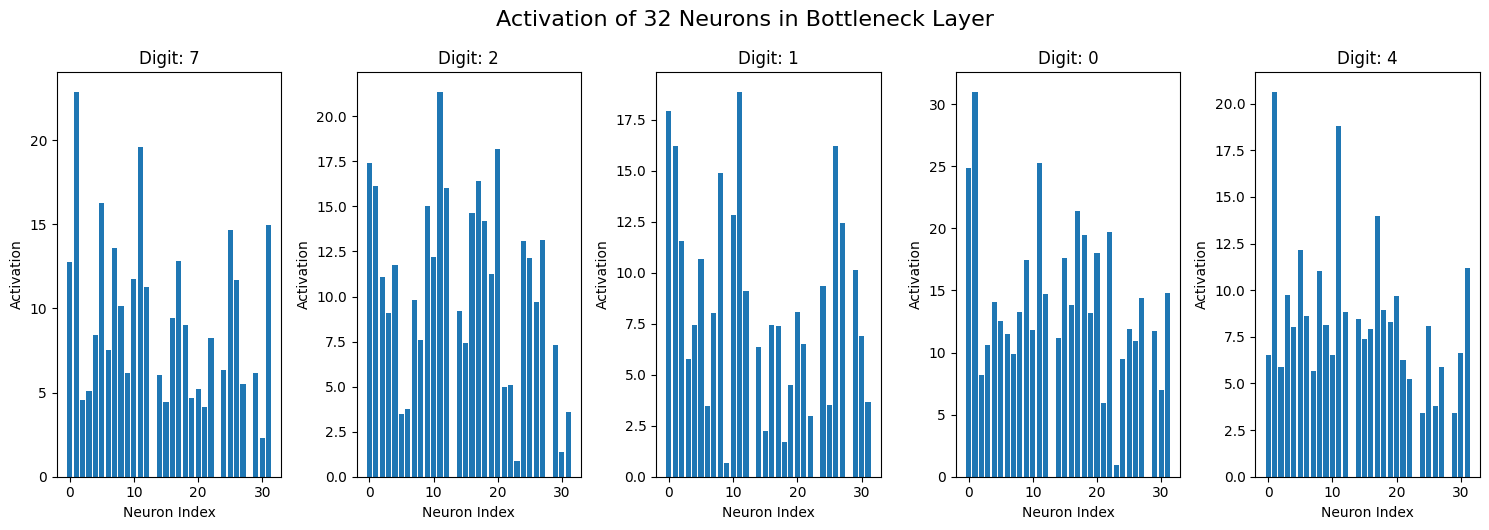

In [ ]:
# For a few test images, look at their 32-dimensional encoded vector
num_images = 5

plt.figure(figsize=(15, 5))
for i in range(num_images):
    encoded_vector = encoded_imgs[i]
    ax = plt.subplot(1, num_images, i + 1)
    plt.bar(range(len(encoded_vector)), encoded_vector)
    plt.title(f"Digit: {y_test[i]}")
    plt.xlabel("Neuron Index")
    plt.ylabel("Activation")
    plt.tight_layout()
plt.suptitle("Activation of 32 Neurons in Bottleneck Layer", y=1.05, fontsize=16)
plt.show()


### Key Points:
> * What This Shows: Each image gets encoded into a unique 32-dimensional vector.
> * The bar chart shows which neurons “light up” (i.e., have high activation values) for different digits.
> * Interpretation: If certain neurons consistently activate for specific types of shapes (e.g., curves for "0", vertical strokes for "1"), they are specialized detectors. Over a larger sample, you may find patterns of dominant neurons per digit.


#### **Analysis 1 & deep interpretation**:
At first glance after looking at the above plot " Visualize Bottleneck Activations per Image" ,I noticed that for digits 7,2,1,0,4 the inactive neurons are {(1,9,12,14,16),(1,9,12,14,16),(1,9,12,14,16,22),(1,9,12,14,16),(1,9,12,14,16,22)} and the most active neuron are : 8,15,7,5,24 with respect to each numbers. But, this scenario completely changed when I run the code again.So, I thought let's discuss about the reason behind it.


> **Reason**:

The variability in specific neuron activations (like "Most Active Neuron") across different training runs, even with identical model architectures, stems from several key factors:

* **Random Initialization of Weights**: Each training session begins with randomly assigned weights and biases, leading to a unique starting point in the model's parameter space.
* **Stochastic Nature of Optimization**: Optimizers like Adam introduce randomness through techniques such as momentum and adaptive learning rates, combined with shuffled data batches, causing the training path to diverge each time.
* **Non-convex Loss Landscape**: The complex, non-convex nature of the loss function means there are multiple sets of weights (local minima) that yield similar performance. The training process converges to one of these varied solutions in each run.

Consequently, while the overall encoding capability of the latent space remains consistent (reflected in similar loss values), the specific features or "tasks" learned by individual neurons within that space can differ. {This is analogous to different team members handling the same tasks in varying assignments, yet achieving the same overall project outcome.}

> Then I realised that,to truly understand what a neuron is "looking for" (i.e., what input features cause it to activate strongly), you typically need techniques that synthesize or identify images that maximize that neuron's activation.Then I found from research a simpler approach for visualization with an autoencoder is to:

1. Find images in your test set that cause a specific neuron to have a high activation.
2. Visualize a few of these original images.

>May be this won't tell us exactly what feature the neuron represents, but it will show us what kinds of digits/patterns tend to strongly activate it.That's the reason why I add a new section below to do this for a few highly active neurons we identified (like neuron 8 for digit 7, neuron 15 for digit 2, etc.)**with keep this in mind that the following visual inspection can give us some intuition about what the neuron might be involved in detecting, but again, it's not a definitive proof that it's only detecting that specific feature.**







#### 🔷 Step 6.2: Visualize Images that Maximize Neuron Activation

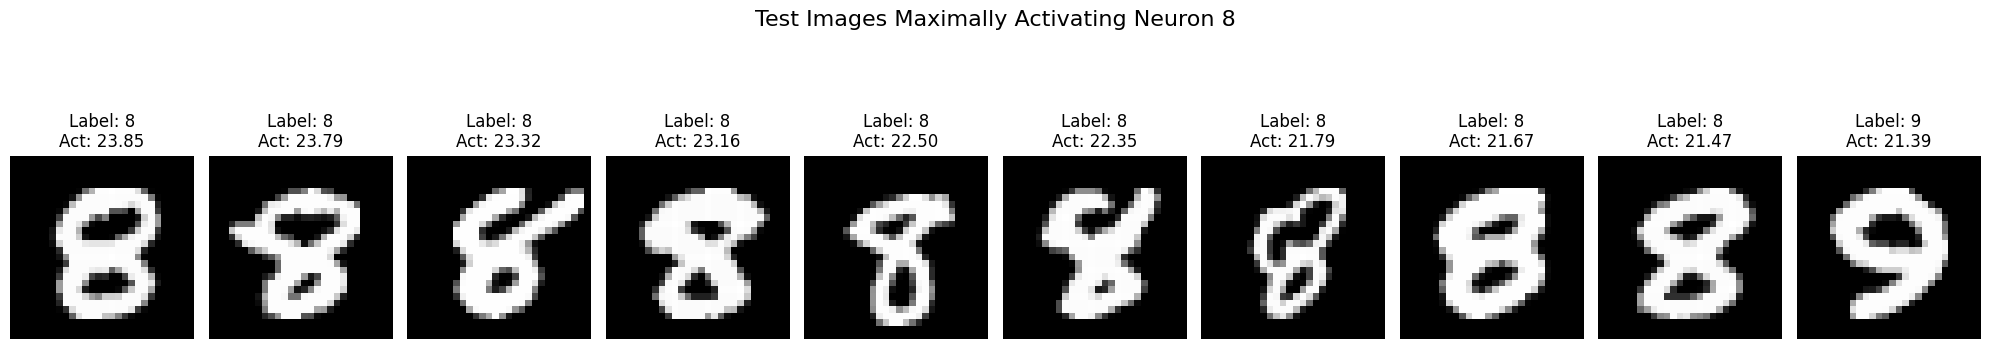

In [ ]:

# To get a sense of what specific neurons might be encoding, let's find test images that cause certain neurons in the latent space to activate strongly and visualize them.

# Choose a neuron index to investigate (e.g., 8, which was active for digit 7)
neuron_to_examine = 8

# Find the indices of test images where this neuron's activation is high
# We'll define "high" as above a certain percentile or absolute value.
# Let's find the top 10 images by activation for this neuron.
top_activation_indices = np.argsort(encoded_imgs[:, neuron_to_examine])[::-1] # Sort in descending order

# Select the top N images
num_top_images = 10
images_with_high_activation = x_test[top_activation_indices[:num_top_images]]
labels_of_top_images = y_test[top_activation_indices[:num_top_images]]
activations_of_top_images = encoded_imgs[top_activation_indices[:num_top_images], neuron_to_examine]


# Plot these images
plt.figure(figsize=(20, 4))
for i in range(num_top_images):
    ax = plt.subplot(1, num_top_images, i + 1)
    plt.imshow(images_with_high_activation[i].reshape(28, 28), cmap='gray')
    plt.title(f"Label: {labels_of_top_images[i]}\nAct: {activations_of_top_images[i]:.2f}")
    plt.axis('off')

plt.suptitle(f"Test Images Maximally Activating Neuron {neuron_to_examine}", y=1.05, fontsize=16)
plt.tight_layout()
plt.show()

# we can repeat this for other neurons that we may identified as highly active:
# neuron_to_examine = 15 # Active for digit 2
# neuron_to_examine = 7  # Active for digit 1
# neuron_to_examine = 5  # Active for digit 0
# neuron_to_examine = 24 # Active for digit 4

### Insight 5:

To gain further intuition about the features encoded within the latent space, we examined test images that maximally activate a specific neuron. For example, we investigated Neuron 8. The plot displays the top [Number of Top Images, e.g., 8] test images that resulted in the highest activation for this neuron.

Upon visual inspection, we observe that the majority of these images correspond to digit [Most Common Digit Label(s), e.g., 8] and may be this aligns with the earlier bar plot analysis which showed high activation for this neuron in the sample digit.

Looking closely at the handwritten forms of these highactivating digits, it appears that Neuron 8 is particularly sensitive to the specific shape(curves/loop) and angle of the top stroke and the downward diagonal stroke that forms the digit 8.

Additionally we need to focus on **Activation Values**, the values should be high for these images, confirming they are indeed the ones causing strong activation for this neuron

However,we you saw a mix of digits(9 also),While the most common digit is 8, we also see images of digit(s) 9. It is interesting to note that these digits may share  "a specific curve or stroke pattern" with the primary digit class 8. This suggests the neuron might be responding to a particular sub feature or visual component that is present in multiple digit forms, rather than the digit as a whole.

This visualization method provides valuable insight by connecting abstract neuron activation back to the concrete visual data. It suggests that the autoencoder has learned to dedicate specific neurons in the latent space to detect or emphasize certain visual characteristics or patterns present in the handwritten digits, which are then used to reconstruct the original image. Repeating this analysis for other neurons that showed high mean activation for different digits would provide a more comprehensive understanding of how the entire latent space collectively encodes the features of the MNIST dataset.

After the step 6, I realised that we shouldn't forget 4 things:

*  1. Introduces variability : The neuron indices might change across training runs (randomness in initialization and training).

* 2. Connects to other analyses: we need o link this variability back to the consistency seen in the t-SNE plot and reconstruction quality. This shows that the overall system is robust, even if the internal neuron assignments are flexible. This demonstrates a deeper understanding.

* 3. Acknowledges limitations & sets up next step: Explicitly state that identifying exact geometric features from just these plots is hard. Transition to the next section (visualizing maximally activating images) as the method to gain more insight into what features the neurons are sensitive to.

Furthermore,we need to keep in our mind that these all outputs are not constant, like if someone in future run this notebook again then different parameters will form and also the behaviour of latent space neuron. we simple word we can say that :" there no fix rule that specific neurons will learns specific features of data, everytime it will behave differently,but the main goal of network is always fixed."

Example: Let's think of it like assigning tasks to a team of 32 people. I need to process some information. One time, Alice might handle the first step and Bob the second. Another time, david might handle the first step and David the second. As long as all steps are covered efficiently by the team, the overall outcome (reconstruction quality) is good, even if the specific person doing a specific step changes.


After this I realised that we need to focus on aggregate behavior (like the heatmap) or the types of features detected, rather than the index of a specific neuron. For example, we might say "certain neurons appear to specialize in detecting horizontal strokes" after visualizing several neurons, rather than saying "neuron 15 detects horizontal strokes."

#### 🔸 6.3: Find Top Neurons for Each Digit (Statistical View)

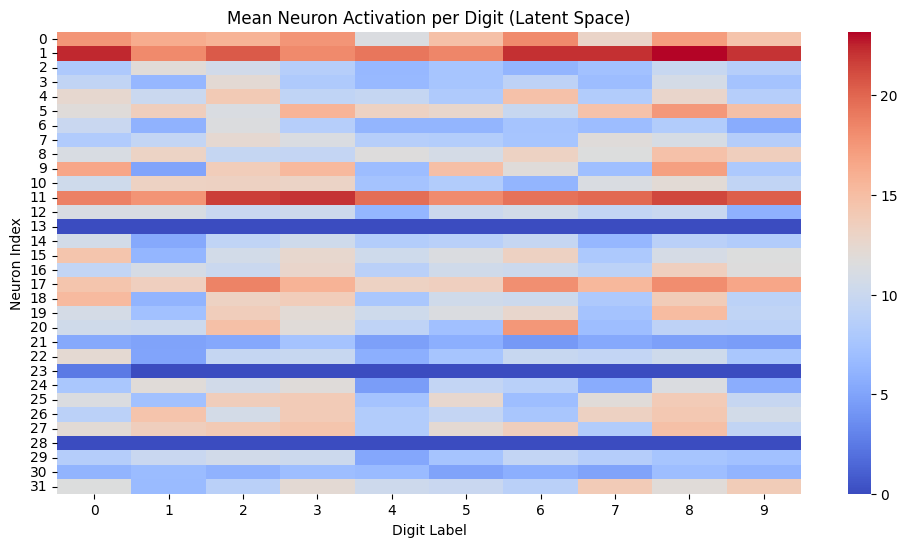

In [ ]:
import pandas as pd

# Create a DataFrame of latent vectors with their true labels
df_features = pd.DataFrame(encoded_imgs)
df_features['label'] = y_test

# Compute mean activation for each neuron by digit
mean_activation_by_digit = df_features.groupby('label').mean().T

# Plot heatmap
plt.figure(figsize=(12, 6))
sns.heatmap(mean_activation_by_digit, cmap='coolwarm', annot=False)
plt.title("Mean Neuron Activation per Digit (Latent Space)")
plt.xlabel("Digit Label")
plt.ylabel("Neuron Index")
plt.show()


### Key points:

> * Neurons vs Digits:
    * Rows: Neurons in the bottleneck (latent) layer.
    * Columns: Digits (0–9). Brighter cells mean higher average activation.

> {After this above plot I realised that The heatmap  provides a statistical overview that complements the individual sample analysis. While we can noticed that the exact pattern might shift if you re train from scratch,but the general idea of which neurons are more important for which classes tends to be somewhat more stable than the specific activation for a single image}. To keep all this in mind, I thought intead discussing about each neuron with respect to each digits, I should discuss about the overall idea and logic behind this.


### Insight 6: Statistical View of Neuron Specialization (Mean Activation)

The heatmap visualizing the mean activation of each latent space neuron (Y-axis) across the different digit classes (X-axis) provides a statistical overview of how the latent space encodes digit information at a class level. The variation in intensity across rows for a given digit column highlights that not all neurons contribute equally to the representation of a specific digit class. Conversely, variations across columns for a given neuron row suggest that some neurons are more active for certain digit classes than others, hinting at a degree of specialization.

While the precise pattern of which neuron index corresponds to which digit's highest mean activation can vary across different training runs (due to random initialization and training dynamics), the heatmap generally reveals that:

1.  **Distributed Representation:** Information about each digit is encoded across multiple neurons, not just one. Different subsets of neurons show higher mean activation for different digits.
2.  **Class Separation:** There are noticeable differences in the mean activation patterns between distinct digit classes. For example, a set of neurons highly active for digit 0 might show low activation for digit 1, reflecting the learned distinction between these classes in the latent space. This supports the observations made in the t-SNE plot, where digits formed separable clusters.
3.  **Potential for Specialization:** Some neurons appear to have significantly higher mean activation for one or a few digit classes compared to others, suggesting they have learned to capture features that are particularly salient for those specific digits.

In summary, this heatmap provides statistical evidence that the unsupervised training of the autoencoder results in a latent space where neurons collectively encode features necessary for reconstructing digits, with some level of specialization emerging for capturing the discriminative characteristics of different handwritten digit classes. (we can also compares heatmap patterns to the class separation observed in the t-SNE plot)

### 🔷 Step 7: Latent Space Manipulation : What Happens If We Tweak the Features?

*  A powerful technique to understand what features are encoded and how smoothly the space represents variations.

#### 🔸7.1: Vary One Latent Neuron at a Time


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step


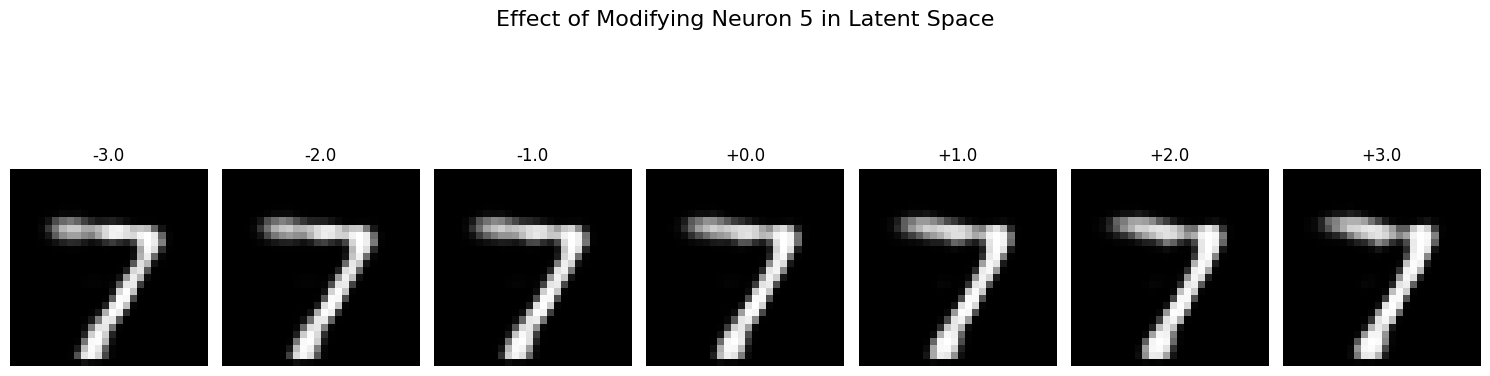

In [ ]:
# Choose one image
index = 0
original = x_test[index].reshape(1, 784)
latent_vector = encoder.predict(original)

# Define the decoder model explicitly
# Start from the input shape of the latent space
latent_input = Input(shape=(32,))
# Replicate the decoder layers from the autoencoder definition
decoder_output = Dense(64, activation='relu')(latent_input)
decoder_output = Dense(128, activation='relu')(decoder_output)
decoder_output = Dense(784, activation='sigmoid')(decoder_output)
decoder = Model(latent_input, decoder_output)

# Set the weights of the new decoder model to match the weights of the autoencoder's decoder part
# The autoencoder layers are: Input (0), Dense (1, encoder), Dense (2, encoder), Dense (3, encoder - latent)
#                            Dense (4, decoder), Dense (5, decoder), Dense (6, decoder - output)
# So, the decoder layers in the autoencoder are autoencoder.layers[4], autoencoder.layers[5], autoencoder.layers[6]
for decoder_layer, autoencoder_layer in zip(decoder.layers[1:], autoencoder.layers[4:]):
    decoder_layer.set_weights(autoencoder_layer.get_weights())


# Create variations by changing one latent neuron
plt.figure(figsize=(15, 4))
neuron_index = 5  # we can change this index to explore different neurons

for i, delta in enumerate(np.linspace(-3, 3, 7)):
    modified_latent = np.array(latent_vector, copy=True)
    modified_latent[0][neuron_index] += delta

    # Decode the modified latent vector using the decoder model
    # Ensure the input to the decoder has the correct shape (batch_size, latent_dim)
    reconstructed = decoder.predict(modified_latent)

    # Show the reconstructed image
    ax = plt.subplot(1, 7, i + 1)
    # Ensure the reconstructed image has the correct shape (28, 28)
    plt.imshow(reconstructed.reshape(28, 28), cmap='gray')
    plt.title(f'{delta:+.1f}')
    plt.axis('off')

plt.suptitle(f"Effect of Modifying Neuron {neuron_index} in Latent Space", y=1.1, fontsize=16)
plt.tight_layout()
plt.show()

### Insight 7: Exploring Latent Space Manipulability (Varying One Neuron)

* To further investigate what specific neurons within the latent space have learned to represent, we performed a latent space manipulation experiment. We selected a single test image (Digit: 7) and obtained its 32-dimensional latent vector. We then systematically varied the activation value of a single neuron (Neuron Index:  5) within this vector, while keeping all other neuron activations constant. The decoder model was then used to reconstruct the image from each modified latent vector. The labels above each image in the plot indicate the amount of change (delta) added to the original activation value of the chosen neuron.

* The plot "Effect of Modifying **Neuron 5** in Latent Space" shows the reconstructed images as the activation of Neuron 5 is varied from  "minimum Delta" : -3.0  to  "Maximum Delta" : +3.0]. The image at +0.0 represents the reconstruction from the original latent vector.

* Observing the transition from Minimum Delta to Maximum Delta, we see "that as the value of Neuron 5 is decreased, the top stroke of the '7' appears to straighten instead of disappear, while increasing the value seems to make it more curved and making it less prominent. This demonstrates that Neuron 5 in the latent space appears to be influencing "the curvature or presence of the top bar".

* It's clear that the digit isn't looking like another digit or becomes distorted (throughout the delta variation it's looking like 7 only).So, we don't need to consider the below concept which indicates that:

> * Pushing the latent vector far from its original value by modifying this single dimension can lead to reconstructions outside the typical distribution of digits, or that the neuron contributes to features shared (or distinct) between different digit classes.

This manipulation confirms that the latent space is not just a random collection of numbers, but rather a structured representation where individual dimensions (neurons) contribute to specific, interpretable visual characteristics of the digits. By varying these dimensions, we can smoothly traverse the space of learned features and see how they combine to form different digit variations.

### 🔷 Step 8: Interpolation Between Digits in Latent Space

#### 🔸8.1: Interpolation Code

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step


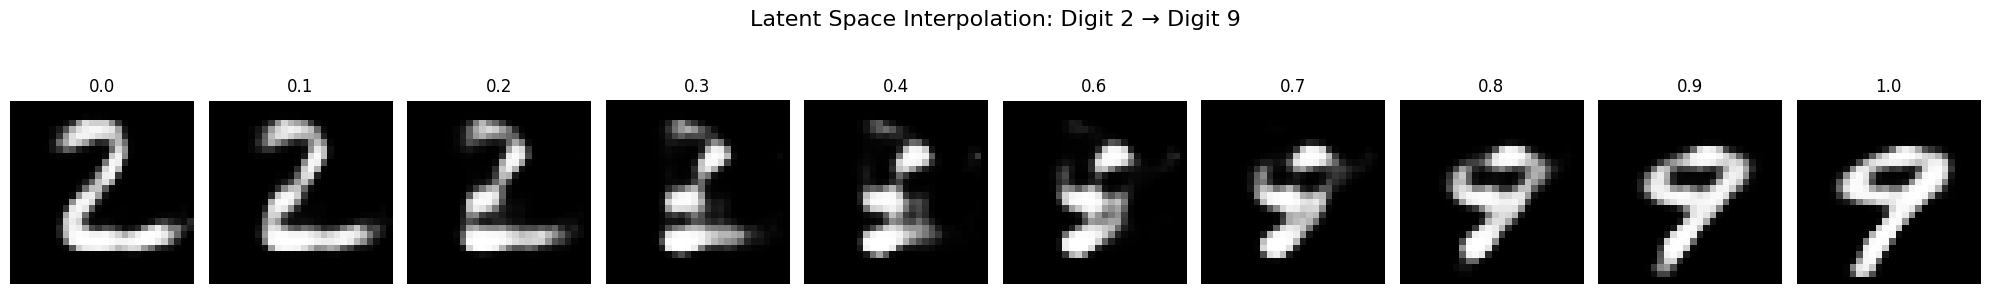

In [ ]:
# Select two digits from test set (adjust the indexes to get other digits)
digit_A_index = 1  # Example: "1"
digit_B_index = 9  # Example: "9"

# Get the encoded representations
z1 = encoder.predict(x_test[digit_A_index:digit_A_index+1])
z2 = encoder.predict(x_test[digit_B_index:digit_B_index+1])

# Create interpolated vectors
alphas = np.linspace(0, 1, 10)  # 10 steps between digit A and B
interpolated = [(1 - alpha) * z1 + alpha * z2 for alpha in alphas]
interpolated = np.array(interpolated)

# Reshape the interpolated array to remove the extra dimension
# The shape should be (batch_size, latent_dim) which is (10, 32)
interpolated = interpolated.reshape(-1, 32)

# Decode the interpolated vectors
decoded_images = decoder.predict(interpolated)

# Plot the interpolated results
plt.figure(figsize=(20, 3))
for i, img in enumerate(decoded_images):
    ax = plt.subplot(1, 10, i + 1)
    plt.imshow(img.reshape(28, 28), cmap='gray')
    plt.title(f'{alphas[i]:.1f}')
    plt.axis('off')
plt.suptitle(f'Latent Space Interpolation: Digit {y_test[digit_A_index]} → Digit {y_test[digit_B_index]}', y=1.05, fontsize=16)
plt.tight_layout()
plt.show()

### Insight 8: Interpolation Between Digits in Latent Space

The latent space of a well-trained autoencoder is expected to be continuous and structured, meaning that moving smoothly through the space should correspond to smooth transitions in the reconstructed image space. To test this, we performed an interpolation experiment between the latent representations of two different test digits: Digit 2 (at alpha=0.0) and Digit 9 (at alpha=1.0). The plot displays reconstructed images from latent vectors that are linearly interpolated between the encoded vectors of these two digits.

Observing the sequence of reconstructed images from left to right (corresponding to increasing alpha values), we see "how the top loop of the '2' gradually elongates and connects while features of the '9', such as the circular base, begin to emerge."

This smooth interpolation suggests that the autoencoder has **learned a continuous and meaningful latent space**. The features that differentiate digits 2 and 9 are not encoded as completely separate, disconnected points, but rather exist along a pathway in the latent space that allows for gradual blending or transformation between their representations.

The ability to smoothly interpolate between different digit classes in the latent space confirms that the autoencoder has learned to capture the underlying manifold of handwritten digits, arranging them in a way that reflects their visual similarities and allows for the exploration of plausible variations.

### 🔷 Step 9: Neuron Sensitivity Analysis — Which Neurons Matter Most?

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━

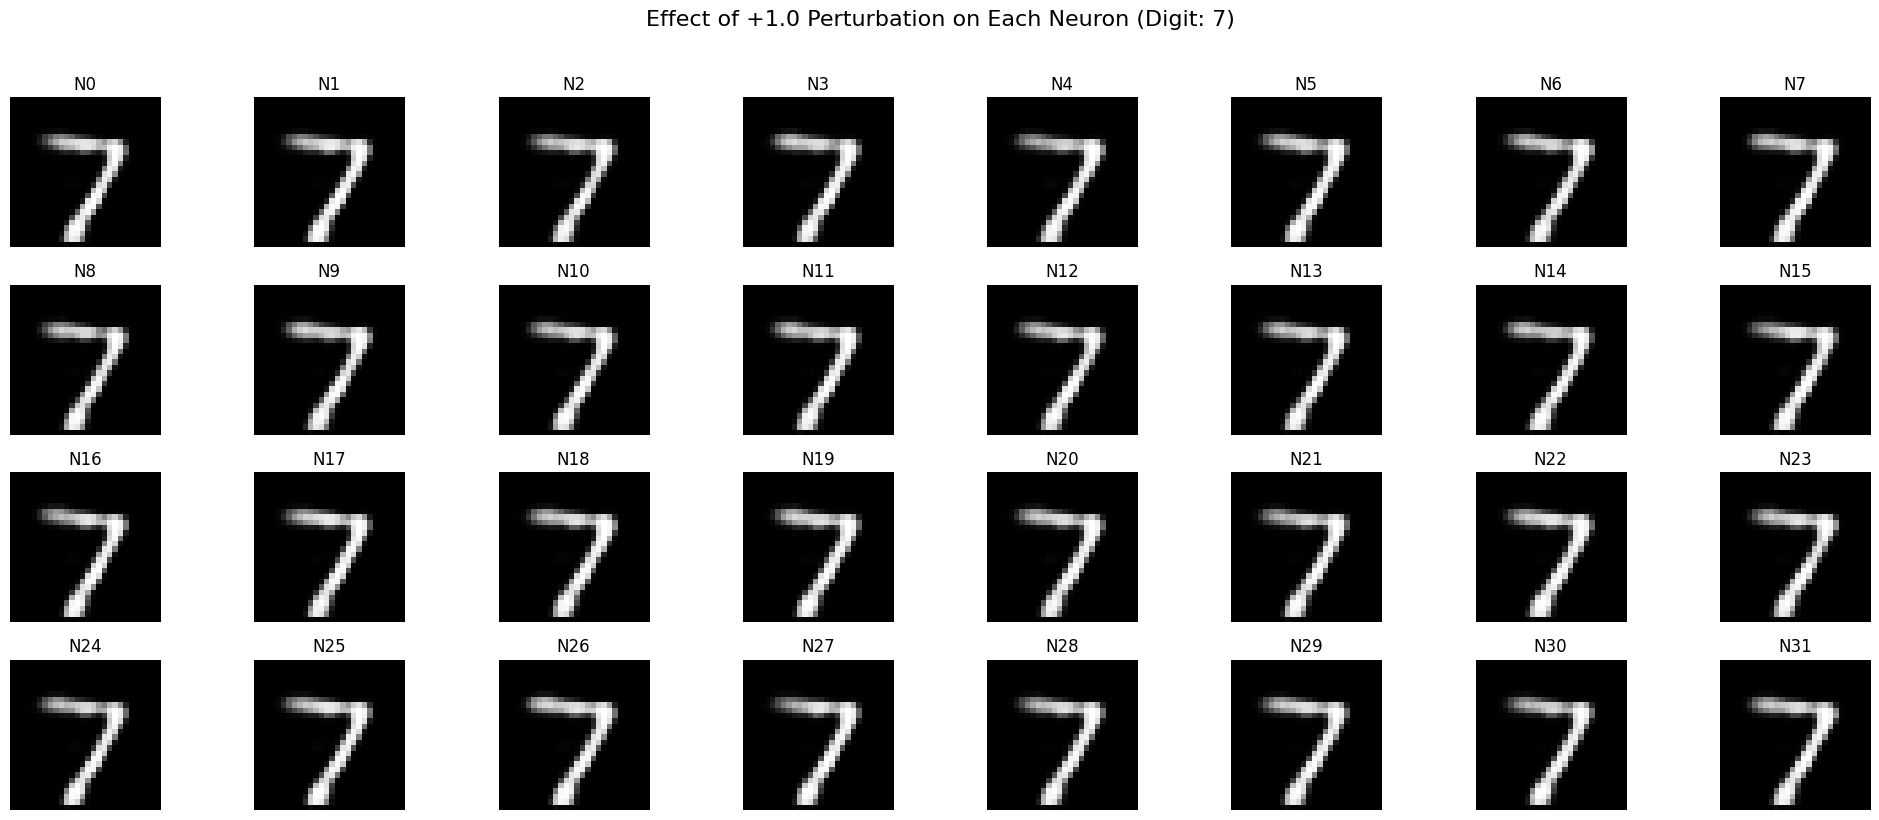

In [ ]:
# Choose one image and encode it
sample_index = 0
original = x_test[sample_index].reshape(1, 784)
latent = encoder.predict(original)

# Perturb each neuron slightly and decode
plt.figure(figsize=(20, 8))

for neuron in range(latent.shape[1]):
    perturbed = np.array(latent, copy=True)
    perturbed[0][neuron] += 1.0  # Small positive perturbation, we can change it to analyse new variation

    reconstructed = decoder.predict(perturbed)

    ax = plt.subplot(4, 8, neuron + 1)
    plt.imshow(reconstructed.reshape(28, 28), cmap='gray')
    plt.title(f'N{neuron}')
    plt.axis('off')

plt.suptitle(f"Effect of +1.0 Perturbation on Each Neuron (Digit: {y_test[sample_index]})", y=1.02, fontsize=16)
plt.tight_layout()
plt.show()


### Insight 9: Neuron Sensitivity Analysis

This experiment **investigates the relative influence of each individual latent neuron on the final reconstructed image for a specific input**. We took the latent vector for a chosen test digit (Digit: 7) and systematically added a fixed perturbation (+1.0) to the activation value of each neuron in isolation, then decoded the modified latent vector. The resulting reconstructed images, labeled by the perturbed neuron's index (N0 to N31), are displayed in the plot "Effect of +1.0 Perturbation on Each Neuron (Digit: 7)".

By comparing these perturbed reconstructions to the original reconstruction (which represents the state with no perturbation), we can visually assess the sensitivity of the decoder to changes in each latent neuron's activation for this specific image.

We observe that Some neurons, like N : 8, 15, 24, appear to have a significant impact on the reconstructed image; perturbing their activation leads to noticeable "blurring",or slight alterations in the shape of the digit 7. This suggests these neurons are highly influential in shaping the output for this particular digit instance.

Other neurons, such as N : 1, 9, 12, show only subtle changes or almost identical reconstructions compared to the original. This indicates they have less influence on the reconstruction of this specific image with this level of perturbation. This could be because they were already close to their "inactive" state for this digit, or their encoded features are less critical for representing this particular instance.

This analysis provides a visual ranking of how much each latent neuron "matters" for reconstructing a given input image. It complements the mean activation analysis by showing the *causal effect* of changing a neuron's value on the output, rather than just its typical activation level. This confirms that the information necessary for reconstruction is encoded differentially across the latent neurons, with some being more influential than others for specific inputs.

# Conclusion

In this project, we successfully built and trained a deep autoencoder on the MNIST dataset, achieving effective reconstruction of handwritten digits from a significantly lower-dimensional latent space (32 dimensions compared to 784 input dimensions). The low training and validation loss, coupled with the visual similarity between original and reconstructed images, confirmed the model's ability to learn meaningful representations of the digit data.

Our analysis of the extracted latent features provided valuable insights into how the autoencoder encodes information in an **unsupervised manner**:

*   The **t-SNE visualization** demonstrated that the learned latent space is effective at separating different digit classes into distinct clusters, indicating that the autoencoder captures features relevant for digit discrimination, even without explicit class labels during training.
*   Examining the **neuron activation patterns** revealed that information about each digit is distributed across multiple latent neurons, with certain neurons showing higher activation for specific digits. While the precise role of individual neurons can vary across training runs due to the stochastic nature of training, the overall principle of differential activation contributes to the distinct latent representations for different digit classes.
*   Further exploration through **latent space manipulation** confirmed the continuous and structured nature of the learned representation. By smoothly varying a single latent neuron's activation or linearly interpolating between the latent vectors of different digits, we observed gradual, meaningful transformations in the reconstructed images. This highlights that the latent space effectively captures the underlying manifold of handwritten digit variations.
*   The **neuron sensitivity analysis** for a specific digit illustrated that the contribution of individual neurons to the final reconstruction varies, providing a visual measure of their relative influence on the output features.

Overall, this analysis demonstrates that the autoencoder effectively compresses high dimensional image data into a lower dimensional latent space by learning a distributed set of features. These features are not necessarily simple, interpretable geometric primitives at the level of individual neurons, but collectively they capture the essential characteristics of handwritten digits necessary for both accurate reconstruction and class separation. The latent space serves as a powerful, compressed representation from which digits can be reconstructed and variations explored, validating the autoencoder's utility for unsupervised feature extraction.

### Future Extension: Exploring Convolutional Autoencoders

While the dense autoencoder proved effective for analyzing the latent space of MNIST digits after flattening, an important extension for image data is the use of Convolutional Autoencoders (CAEs). Unlike the model developed here, CAEs utilize convolutional layers in the encoder and deconvolutional (or transpose convolutional) layers in the decoder, operating directly on the 2D image structure. This approach is particularly well-suited for image processing because it naturally preserves spatial relationships and leverages parameter sharing, making it more efficient and capable of learning hierarchical features like edges, textures, and shapes. Implementing a CAE on MNIST would likely lead to potentially better reconstruction fidelity and might yield a latent space where the learned features are more directly tied to visual patterns within the digits, offering another avenue for in-depth feature analysis.

🔸 With all the above analysis, I deeply felt that:

"**Though the path of reconstruction remains steady and sure, the whispers of meaning in each latent neuron shift like shadows in light capturing glimpses of the digit's soul, yet never bound to a single form. In this dance of abstraction, the autoencoder learns not by rule, but by rhythm, shaping memory from patterns unseen.**"

#### 🔹Personal Reflection and Project Scope Consideration

Initially, I was deeply motivated to apply neural network techniques to cancer prediction, especially in light of personal circumstances involving a family member diagnosed with a neuroendocrine malignancy. However, through careful consideration of the ethical, technical, and practical challenges in the medical domain, I recognized the limitations of deploying deep neural networks for high stakes diagnostic tasks without rigorous validation. In particular, the inherent black box nature of deep models, the need for explainability in clinical settings, and the variability and complexity of cancer related data pose significant barriers. Additionally, achieving clinically acceptable performance often requiring accuracy well above 95%, is difficult without large, high quality, and well annotated datasets. These reflections led me to scope my project toward a domain where I could more confidently control the parameters, interpret results, and build understanding  specifically using autoencoders on the MNIST dataset. Nonetheless, this exploration has strengthened my resolve to contribute meaningfully to medical AI in the future, potentially through explainable models or assistive tools, with a responsible, informed, and research driven approach.